In [1]:
# 라이브러리 임포트
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 차트 설정
plt.style.use('seaborn-v0_8')
%matplotlib inline

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


In [2]:
# 보유 종목 및 수량 입력
portfolio = {
    'JEPI':  120.25,
    'SCHD':  233.46,
    'PDBC':  391.58,
    'TSLA':  18.22,
    'CRCL':  55.25,  # 써클 인터넷 그룹
}

# 데이터 수집 기간
start_date = '2024-01-01'
end_date   = '2025-04-12'

# 주가 데이터 다운로드
tickers = list(portfolio.keys())
prices = yf.download(tickers, start=start_date, end=end_date)['Close']

print(prices.tail())

[**********************80%*************          ]  4 of 5 completed$CRCL: possibly delisted; no price data found  (1d 2024-01-01 -> 2025-04-12) (Yahoo error = "Data doesn't exist for startDate = 1704085200, endDate = 1744430400")
[*********************100%***********************]  5 of 5 completed

1 Failed download:
['CRCL']: possibly delisted; no price data found  (1d 2024-01-01 -> 2025-04-12) (Yahoo error = "Data doesn't exist for startDate = 1704085200, endDate = 1744430400")


Ticker      CRCL       JEPI       PDBC       SCHD        TSLA
Date                                                         
2025-04-07   NaN  47.771145  12.032856  24.012373  233.289993
2025-04-08   NaN  47.026302  11.753694  23.415432  221.860001
2025-04-09   NaN  50.391884  12.235008  24.907784  272.200012
2025-04-10   NaN  49.159679  12.042482  24.041258  252.399994
2025-04-11   NaN  49.637852  12.215755  24.358982  252.309998


In [3]:
# CRCL 티커 확인
crcl = yf.Ticker('CRCL')
print(crcl.info.get('longName', '종목 없음'))
print(crcl.history(period='1mo'))

Circle Internet Group
                                 Open        High         Low       Close  \
Date                                                                        
2026-03-11 00:00:00-04:00  119.800003  123.394997  111.720001  112.809998   
2026-03-12 00:00:00-04:00  113.044998  117.779999  112.150002  114.180000   
2026-03-13 00:00:00-04:00  118.334999  119.300003  113.160004  115.379997   
2026-03-16 00:00:00-04:00  120.150002  126.500000  119.769997  125.830002   
2026-03-17 00:00:00-04:00  124.010002  136.649994  122.739998  132.309998   
2026-03-18 00:00:00-04:00  131.490005  135.485992  128.000000  132.839996   
2026-03-19 00:00:00-04:00  126.324997  129.740005  121.410004  128.330002   
2026-03-20 00:00:00-04:00  127.974998  132.380005  122.910004  126.029999   
2026-03-23 00:00:00-04:00  124.150002  127.480003  121.320000  126.639999   
2026-03-24 00:00:00-04:00  126.349998  127.080002   98.309998  101.169998   
2026-03-25 00:00:00-04:00  106.769997  110.250000  101

In [4]:
# CRCL 제외하고 재다운로드 (상장 역사가 짧아서 제외)
portfolio = {
    'JEPI':  120.25,
    'SCHD':  233.46,
    'PDBC':  391.58,
    'TSLA':  18.22,
}

tickers = list(portfolio.keys())
prices = yf.download(tickers, start='2024-01-01', end='2025-04-12')['Close']

print(f"데이터 shape: {prices.shape}")
print(prices.tail())

[*********************100%***********************]  4 of 4 completed

데이터 shape: (321, 4)
Ticker           JEPI       PDBC       SCHD        TSLA
Date                                                   
2025-04-07  47.771145  12.032856  24.012373  233.289993
2025-04-08  47.026302  11.753694  23.415432  221.860001
2025-04-09  50.391884  12.235008  24.907784  272.200012
2025-04-10  49.159679  12.042482  24.041258  252.399994
2025-04-11  49.637852  12.215755  24.358982  252.309998


In [5]:
# 현재 포트폴리오 가치 계산
shares = pd.Series(portfolio)
latest_prices = prices.iloc[-1]
market_value = shares * latest_prices

total_value = market_value.sum()

print("=== 포트폴리오 현황 ===")
for ticker in tickers:
    print(f"{ticker}: ${market_value[ticker]:,.2f} ({market_value[ticker]/total_value*100:.1f}%)")
print(f"\n총 평가금액: ${total_value:,.2f}")

=== 포트폴리오 현황 ===
JEPI: $5,968.95 (28.4%)
SCHD: $5,686.85 (27.0%)
PDBC: $4,783.45 (22.7%)
TSLA: $4,597.09 (21.9%)

총 평가금액: $21,036.33


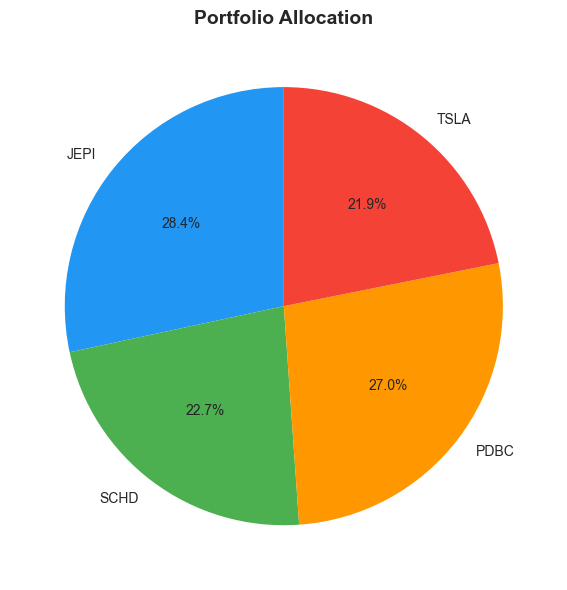

In [6]:
# 포트폴리오 비중 시각화
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
weights = market_value / total_value * 100

ax.pie(weights, 
       labels=tickers, 
       autopct='%1.1f%%',
       colors=colors,
       startangle=90)

ax.set_title('Portfolio Allocation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# 일별 수익률 계산
returns = prices.pct_change().dropna()

# 누적 수익률 계산
cumulative_returns = (1 + returns).cumprod() - 1

print("=== 기간 누적 수익률 ===")
for ticker in tickers:
    ret = cumulative_returns[ticker].iloc[-1] * 100
    print(f"{ticker}: {ret:+.1f}%")

=== 기간 누적 수익률 ===
JEPI: +7.3%
SCHD: +3.6%
PDBC: +0.6%
TSLA: +1.6%


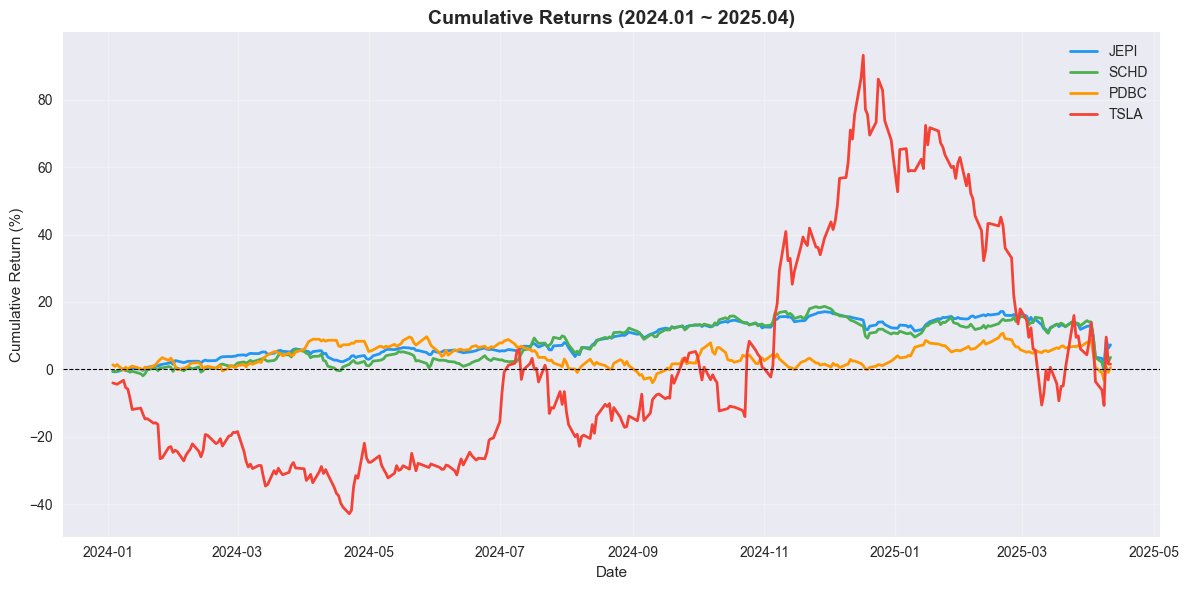

In [8]:
# 누적 수익률 라인차트
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for ticker, color in zip(tickers, colors):
    ax.plot(cumulative_returns.index, 
            cumulative_returns[ticker] * 100,
            label=ticker,
            color=color,
            linewidth=2)

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Cumulative Returns (2024.01 ~ 2025.04)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# 리스크 분석
annual_return = returns.mean() * 252 * 100
annual_volatility = returns.std() * np.sqrt(252) * 100
sharpe_ratio = (returns.mean() * 252) / (returns.std() * np.sqrt(252))

print("=== 리스크 분석 ===")
print(f"{'종목':<8} {'연환산수익률':>12} {'연환산변동성':>12} {'샤프비율':>10}")
print("-" * 45)
for ticker in tickers:
    print(f"{ticker:<8} {annual_return[ticker]:>11.1f}% {annual_volatility[ticker]:>11.1f}% {sharpe_ratio[ticker]:>10.2f}")
    

=== 리스크 분석 ===
종목             연환산수익률       연환산변동성       샤프비율
---------------------------------------------
JEPI             6.3%        12.1%       0.52
SCHD             3.9%        14.8%       0.26
PDBC             1.5%        14.8%       0.10
TSLA            24.5%        69.1%       0.35


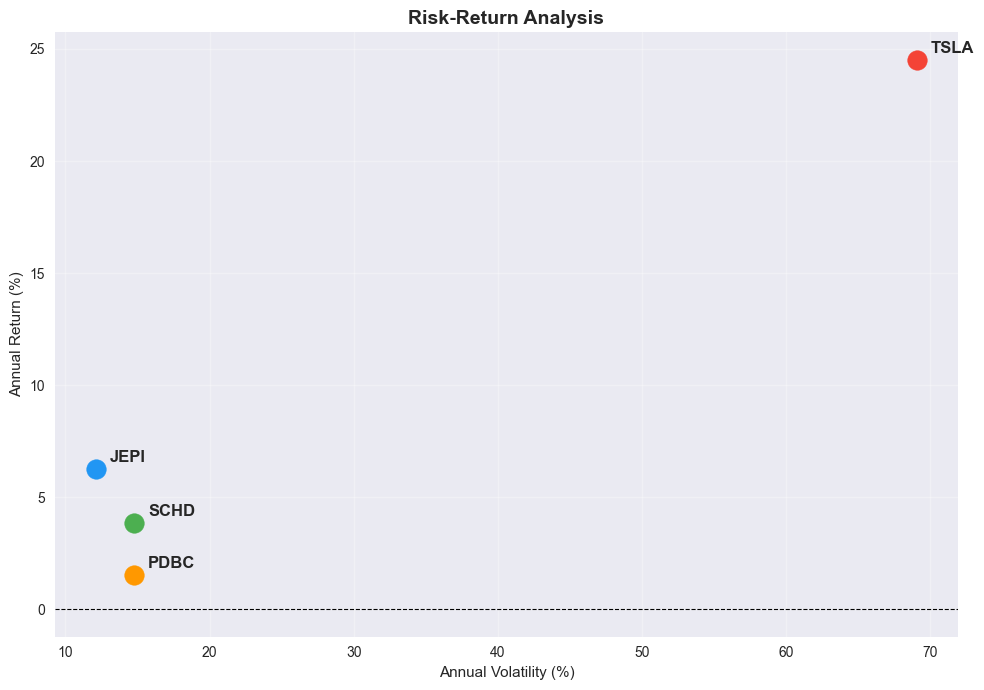

In [10]:
# 리스크-수익률 산점도
fig, ax = plt.subplots(figsize=(10, 7))

for ticker, color in zip(tickers, colors):
    ax.scatter(annual_volatility[ticker], 
               annual_return[ticker],
               s=200, color=color, zorder=5)
    ax.annotate(ticker, 
                (annual_volatility[ticker], annual_return[ticker]),
                textcoords="offset points",
                xytext=(10, 5),
                fontsize=12,
                fontweight='bold')

ax.set_title('Risk-Return Analysis', fontsize=14, fontweight='bold')
ax.set_xlabel('Annual Volatility (%)')
ax.set_ylabel('Annual Return (%)')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# 포트폴리오 전체 성과
weights = market_value / total_value

portfolio_returns = (returns * weights).sum(axis=1)
cumulative_portfolio = (1 + portfolio_returns).cumprod() - 1

portfolio_annual_return = portfolio_returns.mean() * 252 * 100
portfolio_volatility = portfolio_returns.std() * np.sqrt(252) * 100
portfolio_sharpe = (portfolio_returns.mean() * 252) / (portfolio_returns.std() * np.sqrt(252))

print("=== 포트폴리오 전체 성과 ===")
print(f"연환산 수익률: {portfolio_annual_return:.1f}%")
print(f"연환산 변동성: {portfolio_volatility:.1f}%")
print(f"샤프비율: {portfolio_sharpe:.2f}")
print(f"누적 수익률: {cumulative_portfolio.iloc[-1]*100:.1f}%")

=== 포트폴리오 전체 성과 ===
연환산 수익률: 8.5%
연환산 변동성: 20.4%
샤프비율: 0.42
누적 수익률: 8.6%


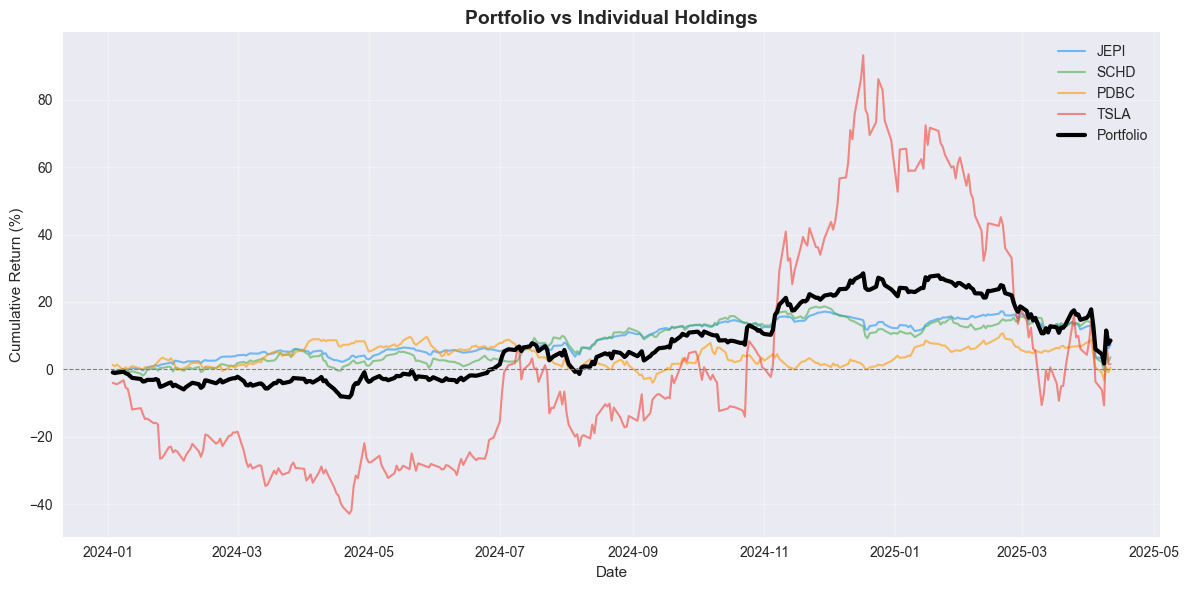

In [13]:
# 개별 종목 + 포트폴리오 전체 비교
fig, ax = plt.subplots(figsize=(12, 6))

for ticker, color in zip(tickers, colors):
    ax.plot(cumulative_returns.index,
            cumulative_returns[ticker] * 100,
            label=ticker,
            color=color,
            linewidth=1.5,
            alpha=0.6)

ax.plot(cumulative_portfolio.index,
        cumulative_portfolio * 100,
        label='Portfolio',
        color='black',
        linewidth=3)

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Portfolio vs Individual Holdings', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# S&P500 벤치마크 데이터 추가
benchmark = yf.download('SPY', start='2024-01-01', end='2025-04-12')['Close'].squeeze()
benchmark_returns = benchmark.pct_change().dropna()
cumulative_benchmark = (1 + benchmark_returns).cumprod() - 1

benchmark_annual_return = float(benchmark_returns.mean() * 252 * 100)
benchmark_volatility = float(benchmark_returns.std() * np.sqrt(252) * 100)
benchmark_sharpe = float((benchmark_returns.mean() * 252) / (benchmark_returns.std() * np.sqrt(252)))

print("=== 벤치마크(S&P500) 성과 ===")
print(f"연환산 수익률: {benchmark_annual_return:.1f}%")
print(f"연환산 변동성: {benchmark_volatility:.1f}%")
print(f"샤프비율: {benchmark_sharpe:.2f}")
print(f"누적 수익률: {cumulative_benchmark.iloc[-1]*100:.1f}%")

[*********************100%***********************]  1 of 1 completed

=== 벤치마크(S&P500) 성과 ===
연환산 수익률: 12.5%
연환산 변동성: 18.1%
샤프비율: 0.69
누적 수익률: 14.8%


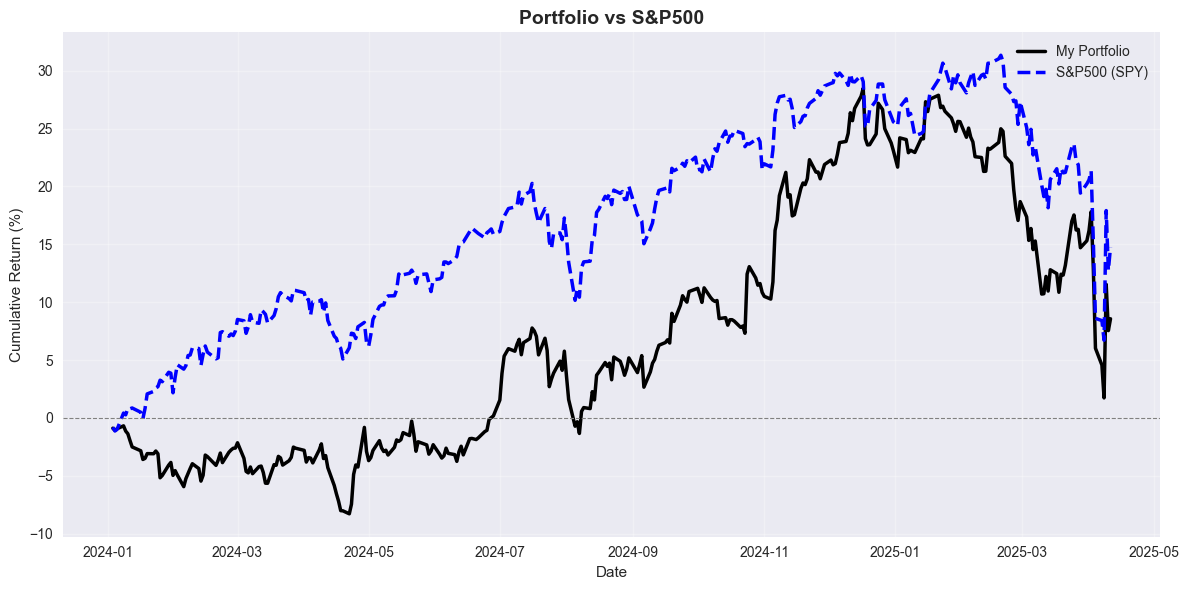

In [16]:
# 포트폴리오 vs 벤치마크 비교 차트
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(cumulative_portfolio.index,
        cumulative_portfolio * 100,
        label='My Portfolio',
        color='black',
        linewidth=2.5)

ax.plot(cumulative_benchmark.index,
        cumulative_benchmark * 100,
        label='S&P500 (SPY)',
        color='blue',
        linewidth=2.5,
        linestyle='--')

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Portfolio vs S&P500', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== 초과수익률 분석 ===
연환산 초과수익률: -3.9%
Tracking Error: 12.4%
Information Ratio: -0.32


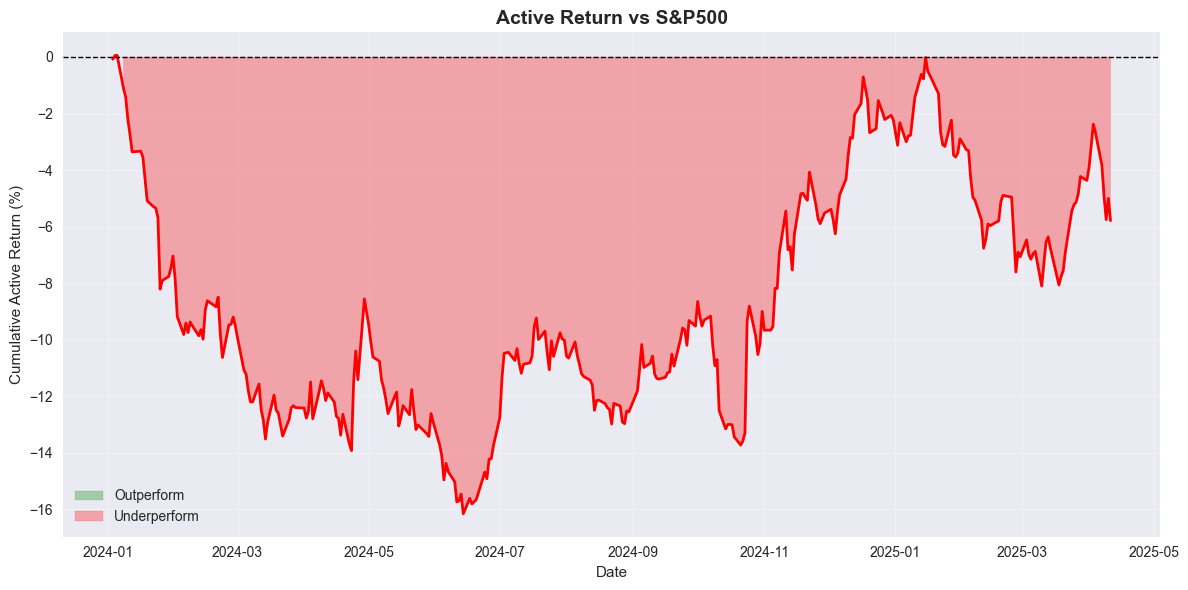

In [17]:
# 초과수익률 분석
# 날짜 인덱스 맞추기
common_dates = portfolio_returns.index.intersection(benchmark_returns.index)
active_returns = portfolio_returns[common_dates] - benchmark_returns[common_dates]
cumulative_active = (1 + active_returns).cumprod() - 1

active_annual = float(active_returns.mean() * 252 * 100)
tracking_error = float(active_returns.std() * np.sqrt(252) * 100)
information_ratio = active_annual / tracking_error

print("=== 초과수익률 분석 ===")
print(f"연환산 초과수익률: {active_annual:.1f}%")
print(f"Tracking Error: {tracking_error:.1f}%")
print(f"Information Ratio: {information_ratio:.2f}")

# 차트
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(common_dates, cumulative_active * 100, color='red', linewidth=2)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.fill_between(common_dates, cumulative_active * 100, 0,
                where=(cumulative_active > 0), alpha=0.3, color='green', label='Outperform')
ax.fill_between(common_dates, cumulative_active * 100, 0,
                where=(cumulative_active < 0), alpha=0.3, color='red', label='Underperform')
ax.set_title('Active Return vs S&P500', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Active Return (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== 종목별 수익률 기여도 ===
JEPI: +1.78%
SCHD: +1.04%
PDBC: +0.35%
TSLA: +5.36%

포트폴리오 합계: +8.53%


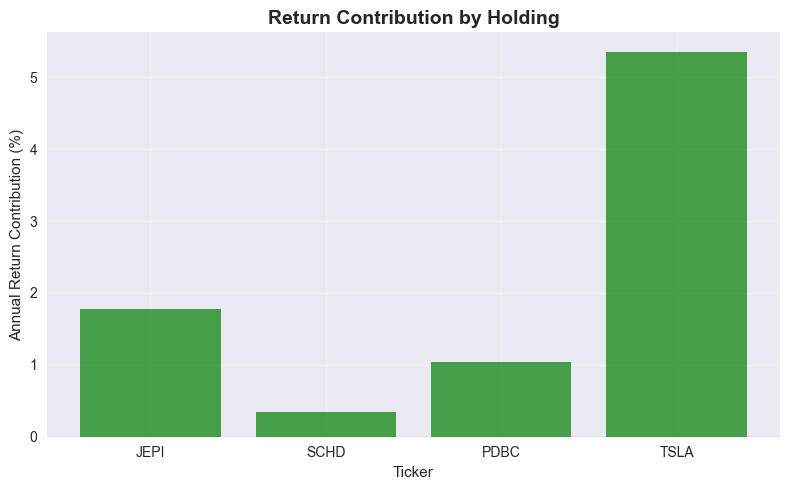

In [18]:
# 종목별 성과 기여도
contribution = returns * weights
annual_contribution = contribution.mean() * 252 * 100

print("=== 종목별 수익률 기여도 ===")
for ticker in tickers:
    print(f"{ticker}: {float(annual_contribution[ticker]):+.2f}%")
print(f"\n포트폴리오 합계: {float(annual_contribution.sum()):+.2f}%")

# 바차트
fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = ['green' if x > 0 else 'red' 
              for x in annual_contribution.values]
ax.bar(tickers, annual_contribution.values, color=colors_bar, alpha=0.7)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Return Contribution by Holding', fontsize=14, fontweight='bold')
ax.set_xlabel('Ticker')
ax.set_ylabel('Annual Return Contribution (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
from scipy.optimize import minimize

# 최적화 함수 정의
def neg_sharpe(weights, returns):
    port_return = np.sum(returns.mean() * weights) * 252
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
    return -port_return / port_vol

# 제약조건 (비중 합계 = 1)
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

# 각 종목 비중 0~1 사이
bounds = tuple((0, 1) for _ in range(len(tickers)))

# 초기값 (균등 비중)
init_weights = np.array([1/len(tickers)] * len(tickers))

# 최적화 실행
result = minimize(neg_sharpe, init_weights,
                  args=(returns,),
                  method='SLSQP',
                  bounds=bounds,
                  constraints=constraints)

optimal_weights = result.x

print("=== 최적 비중 (샤프비율 극대화) ===")
print(f"{'종목':<8} {'현재비중':>10} {'최적비중':>10}")
print("-" * 30)
for ticker, curr, opt in zip(tickers, weights.values, optimal_weights):
    print(f"{ticker:<8} {curr*100:>9.1f}% {opt*100:>9.1f}%")

=== 최적 비중 (샤프비율 극대화) ===
종목             현재비중       최적비중
------------------------------
JEPI          28.4%      94.7%
SCHD          22.7%       0.0%
PDBC          27.0%       0.0%
TSLA          21.9%       5.3%


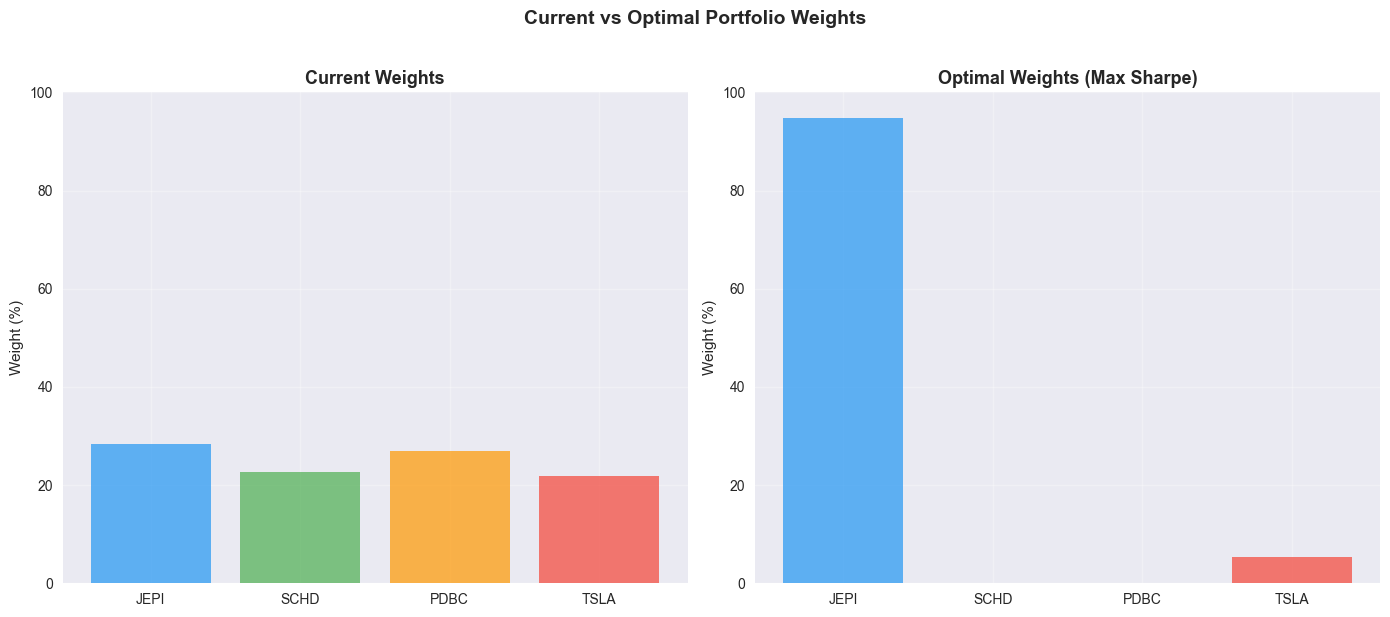

In [20]:
# 현재 vs 최적 비중 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_curr = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
colors_opt = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

# 현재 비중
axes[0].bar(tickers, weights.values * 100, color=colors_curr, alpha=0.7)
axes[0].set_title('Current Weights', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Weight (%)')
axes[0].set_ylim(0, 100)
axes[0].grid(True, alpha=0.3)

# 최적 비중
axes[1].bar(tickers, optimal_weights * 100, color=colors_opt, alpha=0.7)
axes[1].set_title('Optimal Weights (Max Sharpe)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Weight (%)')
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Current vs Optimal Portfolio Weights', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# CRCL 포함, 전체 재분석
portfolio = {
    'JEPI':  120.25,
    'SCHD':  233.46,
    'PDBC':  391.58,
    'TSLA':  18.22,
    'CRCL':  55.25,
}

tickers = list(portfolio.keys())
prices = yf.download(tickers, start='2025-06-05', end='2026-04-12')['Close']

print(f"데이터 shape: {prices.shape}")
print(prices.tail())

[*********************100%***********************]  5 of 5 completed

데이터 shape: (213, 5)
Ticker           CRCL       JEPI       PDBC       SCHD        TSLA
Date                                                              
2026-04-06  92.150002  56.700001  17.549999  30.639999  352.820007
2026-04-07  94.120003  56.520000  17.520000  30.559999  346.649994
2026-04-08  94.440002  57.610001  17.010000  30.860001  343.250000
2026-04-09  85.099998  57.799999  17.120001  30.940001  345.619995
2026-04-10  88.040001  57.540001  16.969999  30.559999  348.950012


In [22]:
# 포트폴리오 가치 재계산
shares = pd.Series(portfolio)
latest_prices = prices.iloc[-1]
market_value = shares * latest_prices
total_value = market_value.sum()

print("=== 포트폴리오 현황 (CRCL 포함) ===")
for ticker in tickers:
    print(f"{ticker}: ${market_value[ticker]:,.2f} ({market_value[ticker]/total_value*100:.1f}%)")
print(f"\n총 평가금액: ${total_value:,.2f}")

# 수익률 계산
returns = prices.pct_change().dropna()
cumulative_returns = (1 + returns).cumprod() - 1

print("\n=== 기간 누적 수익률 ===")
for ticker in tickers:
    ret = cumulative_returns[ticker].iloc[-1] * 100
    print(f"{ticker}: {ret:+.1f}%")

=== 포트폴리오 현황 (CRCL 포함) ===
JEPI: $6,919.19 (21.7%)
SCHD: $7,134.54 (22.4%)
PDBC: $6,645.11 (20.8%)
TSLA: $6,357.87 (19.9%)
CRCL: $4,864.21 (15.2%)

총 평가금액: $31,920.91

=== 기간 누적 수익률 ===
JEPI: +10.1%
SCHD: +21.0%
PDBC: +36.8%
TSLA: +22.6%
CRCL: +5.8%


In [23]:
# 리스크 분석 재계산
weights = market_value / total_value
annual_return = returns.mean() * 252 * 100
annual_volatility = returns.std() * np.sqrt(252) * 100
sharpe_ratio = (returns.mean() * 252) / (returns.std() * np.sqrt(252))

print("=== 리스크 분석 ===")
print(f"{'종목':<8} {'연환산수익률':>12} {'연환산변동성':>12} {'샤프비율':>10}")
print("-" * 45)
for ticker in tickers:
    print(f"{ticker:<8} {float(annual_return[ticker]):>11.1f}% {float(annual_volatility[ticker]):>11.1f}% {float(sharpe_ratio[ticker]):>10.2f}")

# 포트폴리오 전체
portfolio_returns = (returns * weights).sum(axis=1)
port_annual = float(portfolio_returns.mean() * 252 * 100)
port_vol = float(portfolio_returns.std() * np.sqrt(252) * 100)
port_sharpe = port_annual / port_vol

print("-" * 45)
print(f"{'Portfolio':<8} {port_annual:>11.1f}% {port_vol:>11.1f}% {port_sharpe:>10.2f}")


=== 리스크 분석 ===
종목             연환산수익률       연환산변동성       샤프비율
---------------------------------------------
JEPI            11.8%         8.2%       1.44
SCHD            23.3%        11.1%       2.10
PDBC            38.9%        18.2%       2.14
TSLA            34.1%        44.6%       0.76
CRCL            72.3%       118.2%       0.61
---------------------------------------------
Portfolio        33.7%        23.6%       1.43


[*********************100%***********************]  1 of 1 completed


=== 포트폴리오 vs S&P500 ===
                       포트폴리오     S&P500
----------------------------------------
연환산수익률                 33.7%      18.3%
연환산변동성                 23.6%      12.1%
샤프비율                    1.43       1.51


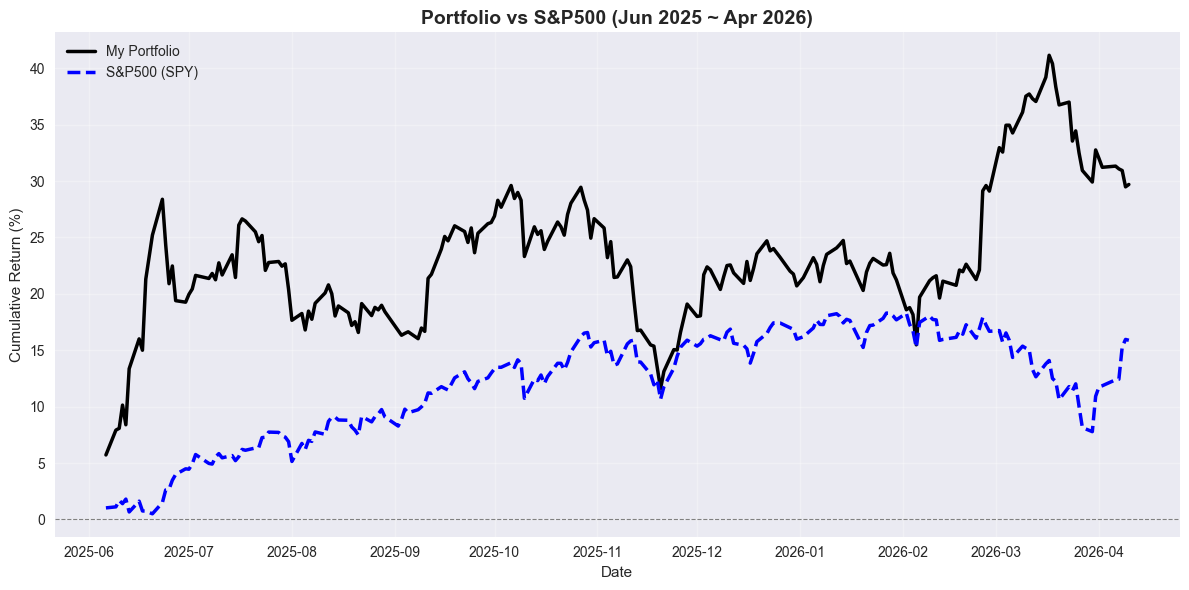

In [24]:
# 벤치마크 재다운로드
benchmark = yf.download('SPY', start='2025-06-05', end='2026-04-12')['Close'].squeeze()
benchmark_returns = benchmark.pct_change().dropna()
cumulative_benchmark = (1 + benchmark_returns).cumprod() - 1

benchmark_annual = float(benchmark_returns.mean() * 252 * 100)
benchmark_vol = float(benchmark_returns.std() * np.sqrt(252) * 100)
benchmark_sharpe = benchmark_annual / benchmark_vol

cumulative_portfolio = (1 + portfolio_returns).cumprod() - 1

print("=== 포트폴리오 vs S&P500 ===")
print(f"{'':15} {'포트폴리오':>12} {'S&P500':>10}")
print("-" * 40)
print(f"{'연환산수익률':<15} {port_annual:>11.1f}% {benchmark_annual:>9.1f}%")
print(f"{'연환산변동성':<15} {port_vol:>11.1f}% {benchmark_vol:>9.1f}%")
print(f"{'샤프비율':<15} {port_sharpe:>12.2f} {benchmark_sharpe:>10.2f}")

# 비교 차트
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cumulative_portfolio.index,
        cumulative_portfolio * 100,
        label='My Portfolio', color='black', linewidth=2.5)
ax.plot(cumulative_benchmark.index,
        cumulative_benchmark * 100,
        label='S&P500 (SPY)', color='blue', linewidth=2.5, linestyle='--')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Portfolio vs S&P500 (Jun 2025 ~ Apr 2026)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# 최적 비중 계산
def neg_sharpe(w, returns):
    port_return = np.sum(returns.mean() * w) * 252
    port_vol = np.sqrt(np.dot(w.T, np.dot(returns.cov() * 252, w)))
    return -port_return / port_vol

constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
bounds = tuple((0, 1) for _ in range(len(tickers)))
init_weights = np.array([1/len(tickers)] * len(tickers))

result = minimize(neg_sharpe, init_weights,
                  args=(returns,),
                  method='SLSQP',
                  bounds=bounds,
                  constraints=constraints)

optimal_weights = result.x

print("=== 현재 vs 최적 비중 ===")
print(f"{'종목':<8} {'현재비중':>10} {'최적비중':>10}")
print("-" * 30)
for ticker, curr, opt in zip(tickers, weights.values, optimal_weights):
    print(f"{ticker:<8} {curr*100:>9.1f}% {opt*100:>9.1f}%")

opt_return = float(np.sum(returns.mean() * optimal_weights) * 252 * 100)
opt_vol = float(np.sqrt(np.dot(optimal_weights.T, 
               np.dot(returns.cov() * 252, optimal_weights))) * 100)
opt_sharpe = opt_return / opt_vol

print(f"\n최적 포트폴리오 샤프비율: {opt_sharpe:.2f}")
print(f"현재 포트폴리오 샤프비율: {port_sharpe:.2f}")

=== 현재 vs 최적 비중 ===
종목             현재비중       최적비중
------------------------------
JEPI          15.2%       0.1%
SCHD          21.7%      32.9%
PDBC          20.8%      34.5%
TSLA          22.4%      30.8%
CRCL          19.9%       1.7%

최적 포트폴리오 샤프비율: 3.04
현재 포트폴리오 샤프비율: 1.43


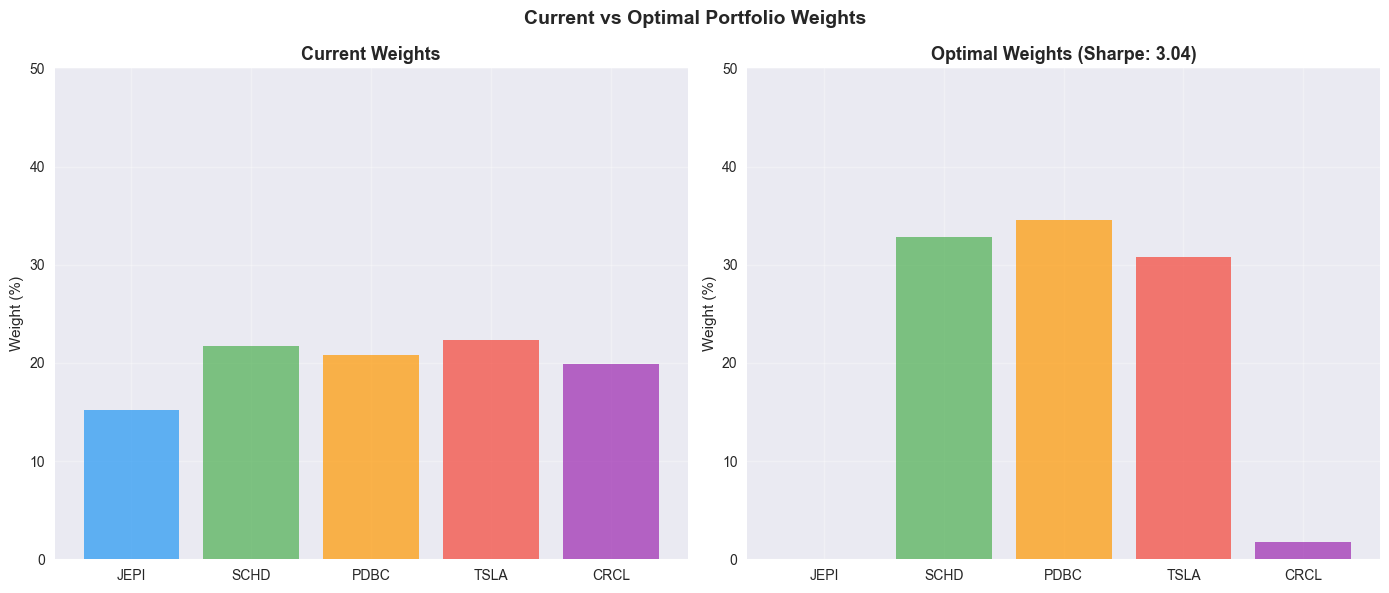


✅ 분석 완료!
현재 샤프비율: 1.43 → 최적 샤프비율: 3.04
개선 가능 여지: +1.61


In [27]:
# 현재 vs 최적 비중 비교 차트
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_chart = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']

axes[0].bar(tickers, weights.values * 100, color=colors_chart, alpha=0.7)
axes[0].set_title('Current Weights', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Weight (%)')
axes[0].set_ylim(0, 50)
axes[0].grid(True, alpha=0.3)

axes[1].bar(tickers, optimal_weights * 100, color=colors_chart, alpha=0.7)
axes[1].set_title(f'Optimal Weights (Sharpe: {opt_sharpe:.2f})', 
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Weight (%)')
axes[1].set_ylim(0, 50)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Current vs Optimal Portfolio Weights',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ 분석 완료!")
print(f"현재 샤프비율: {port_sharpe:.2f} → 최적 샤프비율: {opt_sharpe:.2f}")
print(f"개선 가능 여지: +{opt_sharpe - port_sharpe:.2f}")

In [32]:
# KODEX 한국부동산리츠인프라 티커 확인
kodex = yf.Ticker('476800.KS')
hist = kodex.history(period='1mo')
print(hist.tail())

                             Open    High     Low   Close   Volume  Dividends  \
Date                                                                            
2026-04-06 00:00:00+09:00  4890.0  4900.0  4865.0  4890.0   962000        0.0   
2026-04-07 00:00:00+09:00  4900.0  4905.0  4885.0  4895.0   834805        0.0   
2026-04-08 00:00:00+09:00  4905.0  4920.0  4895.0  4915.0   924902        0.0   
2026-04-09 00:00:00+09:00  4925.0  4940.0  4905.0  4930.0   848780        0.0   
2026-04-10 00:00:00+09:00  4935.0  4980.0  4935.0  4980.0  1046366        0.0   

                           Stock Splits  Capital Gains  
Date                                                    
2026-04-06 00:00:00+09:00           0.0            0.0  
2026-04-07 00:00:00+09:00           0.0            0.0  
2026-04-08 00:00:00+09:00           0.0            0.0  
2026-04-09 00:00:00+09:00           0.0            0.0  
2026-04-10 00:00:00+09:00           0.0            0.0  


In [33]:
# 환율 데이터 가져오기 (USD/KRW)
usdkrw = yf.download('KRW=X', start='2025-06-05', end='2026-04-12')['Close'].squeeze()

# KODEX 데이터 가져오기
kodex_prices = yf.download('476800.KS', start='2025-06-05', end='2026-04-12')['Close'].squeeze()

# 날짜 인덱스 timezone 제거
kodex_prices.index = kodex_prices.index.tz_localize(None)

# 환율 적용해서 달러로 변환
kodex_usd = kodex_prices / usdkrw

print("KODEX (USD 환산) 최근 5일:")
print(kodex_usd.tail())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

KODEX (USD 환산) 최근 5일:
Date
2026-04-07    3.246344
2026-04-08    3.278568
2026-04-09    3.336492
2026-04-10    3.380213
2026-04-11         NaN
dtype: float64


In [34]:
# 전체 포트폴리오 재구성 (KODEX 추가)
portfolio_full = {
    'JEPI':  120.25,
    'SCHD':  233.46,
    'PDBC':  391.58,
    'TSLA':  18.22,
    'CRCL':  55.25,
    'KODEX': 1600,
}

# 해외주식 데이터
tickers_us = ['JEPI', 'SCHD', 'PDBC', 'TSLA', 'CRCL']
prices_us = yf.download(tickers_us, start='2025-06-05', end='2026-04-12')['Close']

# KODEX USD 환산 데이터 합치기
prices_full = prices_us.copy()
prices_full['KODEX'] = kodex_usd

# NaN 제거
prices_full = prices_full.dropna()

print(f"데이터 shape: {prices_full.shape}")
print(prices_full.tail())

[*********************100%***********************]  5 of 5 completed

데이터 shape: (202, 6)
Ticker           CRCL       JEPI       PDBC       SCHD        TSLA     KODEX
Date                                                                        
2026-04-06  92.150002  56.700001  17.549999  30.639999  352.820007  3.239998
2026-04-07  94.120003  56.520000  17.520000  30.559999  346.649994  3.246344
2026-04-08  94.440002  57.610001  17.010000  30.860001  343.250000  3.278568
2026-04-09  85.099998  57.799999  17.120001  30.940001  345.619995  3.336492
2026-04-10  88.040001  57.540001  16.969999  30.559999  348.950012  3.380213


In [35]:
# 포트폴리오 가치 재계산
tickers_full = list(portfolio_full.keys())
shares_full = pd.Series(portfolio_full)
latest_prices_full = prices_full.iloc[-1]
market_value_full = shares_full * latest_prices_full
total_value_full = market_value_full.sum()

print("=== 포트폴리오 현황 (KODEX 포함) ===")
for ticker in tickers_full:
    print(f"{ticker}: ${market_value_full[ticker]:,.2f} ({market_value_full[ticker]/total_value_full*100:.1f}%)")
print(f"\n총 평가금액: ${total_value_full:,.2f}")

# 수익률 계산
returns_full = prices_full.pct_change().dropna()
cumulative_returns_full = (1 + returns_full).cumprod() - 1

print("\n=== 기간 누적 수익률 ===")
for ticker in tickers_full:
    ret = cumulative_returns_full[ticker].iloc[-1] * 100
    print(f"{ticker}: {ret:+.1f}%")
    

=== 포트폴리오 현황 (KODEX 포함) ===
JEPI: $6,919.19 (18.5%)
SCHD: $7,134.54 (19.1%)
PDBC: $6,645.11 (17.8%)
TSLA: $6,357.87 (17.0%)
CRCL: $4,864.21 (13.0%)
KODEX: $5,408.34 (14.5%)

총 평가금액: $37,329.25

=== 기간 누적 수익률 ===
JEPI: +10.1%
SCHD: +21.0%
PDBC: +36.8%
TSLA: +22.6%
CRCL: +5.8%
KODEX: +3.4%
